In [1]:

!pip install datasets

In [2]:
from datasets import load_dataset

ds = load_dataset("knkarthick/dialogsum")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/11.3M [00:00<?, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/12460 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [3]:
ds

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1500
    })
})

In [4]:
ds['train'][1]['dialogue']

"#Person1#: Hello Mrs. Parker, how have you been?\n#Person2#: Hello Dr. Peters. Just fine thank you. Ricky and I are here for his vaccines.\n#Person1#: Very well. Let's see, according to his vaccination record, Ricky has received his Polio, Tetanus and Hepatitis B shots. He is 14 months old, so he is due for Hepatitis A, Chickenpox and Measles shots.\n#Person2#: What about Rubella and Mumps?\n#Person1#: Well, I can only give him these for now, and after a couple of weeks I can administer the rest.\n#Person2#: OK, great. Doctor, I think I also may need a Tetanus booster. Last time I got it was maybe fifteen years ago!\n#Person1#: We will check our records and I'll have the nurse administer and the booster as well. Now, please hold Ricky's arm tight, this may sting a little."

In [5]:
ds['train'][1]['summary']

'Mrs Parker takes Ricky for his vaccines. Dr. Peters checks the record and then gives Ricky a vaccine.'

In [6]:
!pip install transformers

In [7]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("summarization", model="facebook/bart-large-cnn")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [8]:
article_1=ds['train'][1]['dialogue']

In [9]:
pipe(article_1,max_length=20,min_length=10,do_sample=False)

[{'summary_text': 'Ricky has received his Polio, Tetanus and Hepatitis B shots.'}]

In [10]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large-cnn")
model = AutoModelForSeq2SeqLM.from_pretrained("facebook/bart-large-cnn")

In [11]:
def preprocess_function(batch):
  source=batch['dialogue']
  target=batch['summary']
  source_ids=tokenizer(source,truncation=True,padding='max_length',max_length=128)
  target_ids=tokenizer(target,truncation=True,padding='max_length',max_length=128)
  labels=target_ids['input_ids']
  labels=[[(label if label != tokenizer.pad_token_type_id else -100) for label in labels_example]for labels_example in labels]
  return{
      'input_ids':source_ids['input_ids'],
      'attention_mask':source_ids['attention_mask'],
      'labels':labels,
  }

In [12]:
df_source=ds.map(preprocess_function,batched=True)

Map:   0%|          | 0/12460 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [13]:
from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(
      output_dir="/content",
      per_device_train_batch_size=8,
      num_train_epochs=2,
      remove_unused_columns=True
  )


In [14]:
trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=df_source['train'],
    eval_dataset=df_source['test']
)

In [15]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: soumyasucharita710 (soumyasucharita710-nist) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,2.140300
1000,1.672900
1500,1.608100
2000,1.510200
2500,1.470500
3000,1.458300


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=3116, training_loss=1.637715002997696, metrics={'train_runtime': 3957.8845, 'train_samples_per_second': 6.296, 'train_steps_per_second': 0.787, 'total_flos': 6750530835578880.0, 'train_loss': 1.637715002997696, 'epoch': 2.0})

In [16]:
eval_results=trainer.evaluate()

In [17]:
eval_results

{'eval_loss': 10.583226203918457,
 'eval_runtime': 42.3542,
 'eval_samples_per_second': 35.416,
 'eval_steps_per_second': 4.439,
 'epoch': 2.0}

In [18]:
model.save_pretrained('/content/model_directory')
tokenizer.save_pretrained('/content/model_directory')

('/content/model_directory/tokenizer_config.json',
 '/content/model_directory/special_tokens_map.json',
 '/content/model_directory/vocab.json',
 '/content/model_directory/merges.txt',
 '/content/model_directory/added_tokens.json',
 '/content/model_directory/tokenizer.json')

In [19]:
tokenizer=AutoTokenizer.from_pretrained('/content/model_directory')
model=AutoModelForSeq2SeqLM.from_pretrained('/content/model_directory')

/usr/local/lib/python3.12/dist-packages/transformers/models/bart/configuration_bart.py:177: UserWarning: Please make sure the config includes `forced_bos_token_id=0` in future versions. The config can simply be saved and uploaded again to be fixed.
  warnings.warn(


In [20]:
# def summarize(blog_post):
#   inputs=tokenizer(blog_post,max_length=1024,truncation=True,return_tensors='pt')
#   summary_ids=model.generate(inputs['input_ids'],max_length=150,min_length=40,length_penalty=2.0,num_beams=4,early_stopping=True)
#   summary=tokenizer.decode(summary_ids[0],skip_special_tokens=True)
#   return summary

In [21]:
# from transformers import BartForConditionalGeneration, BartTokenizer

# def summarize(text):
#     inputs = tokenizer([text], max_length=1024, truncation=True, return_tensors="pt")

#     summary_ids = model.generate(
#         inputs["input_ids"],
#         num_beams=4,
#         length_penalty=2.0,
#         max_length=120,
#         min_length=40,
#         early_stopping=True
#     )

#     return tokenizer.decode(summary_ids[0], skip_special_tokens=True)


In [22]:
from transformers import BartForConditionalGeneration, BartTokenizer

tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
model = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn")

def summarize(text):
    inputs = tokenizer(text, max_length=1024, truncation=True, return_tensors="pt")

    summary_ids = model.generate(
        inputs["input_ids"],
        num_beams=4,
        max_length=150,
        min_length=40,
        early_stopping=True
    )

    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary


In [23]:
blog=""" As Yogi Berra famously said, it’s tough to make predictions, especially about the future. But had the baseball legend spent any time observing the UN climate negotiations, he could have safely predicted that climate finance will prove to be a key sticking point at COP29 in Baku at the end of this year.

‘Who will pay and how much?’ are perennial questions at the climate talks, but this year, the discussions about climate finance will be especially prominent. At COP29, Parties to the Paris Agreement must negotiate a new climate finance goal, to replace the existing commitment from 2009 for developed countries to provide US$100 billion climate finance annually from 2020 to 2025 - a commitment that only in 2022 was starting to be fulfilled, according to a recent OECD report.

It is vital that the forthcoming Bonn Climate Change Conference sends the right political signals, and lays the procedural and technical groundwork for an ambitious climate finance deal in Baku.

A pressing need

With global warming already destabilising the climate and devastating people’s lives and livelihoods, the need for finance to reduce greenhouse gas emissions and to adapt to a warming world has never been more pressing.

The sums involved are large. The Paris Agreement’s Global Stocktake process estimates that US$5.8-5.9 trillion is required to implement Nationally Determined Contributions (NDCs) in developing countries up to 2030. They will require US$215-387 billion annually over this period for adaptation. Investments of US$1.5 trillion in renewable energy are required worldwide every year up until 2030, according to IRENA.

But these sums are also affordable and beneficial for developed countries. They should be seen in the context of ongoing investments in energy and other infrastructure: around US$2.3 trillion was invested in energy infrastructure in 2023, of which US$1.74 trillion was in clean energy. These investments will generate strong returns for their investors and reduce the costs for energy consumers.

And, crucially, they should also be seen in the context of the alternative. The latest research estimates that the world economy is already set to face a 19% income reduction within the next 26 years based on the levels of warming we have already locked in. The more we delay and the more the planet heats, the greater the economic costs will be.

Laying the foundations for a new finance goal

While financial resources are beginning to flow, they are not flowing fast enough, and certainly not flowing to those developing countries where need is greatest and access to finance is most challenging.

The UN climate framework provides mechanisms that can enable those flows of climate finance. Back in 2015, parties at the climate talks agreed to establish a “new collective quantified goal” (NCQG) for climate finance. They agreed that the NCQG would be set prior to 2025.

The  ultimate size of the NCQG will be a product of the negotiations, but Parties have agreed it must be a significant increase from the floor of US$100 billion annually. For WWF, it must be needs-based and sufficiently ambitious to meet the scale of the challenge we face, and immediately accessible to help countries that are already facing the chaos of a destabilised climate system.

While developed countries are expected to provide financial and technical support, developing countries also have a role to play. Parties are due to submit revised NDCs in 2025, presenting how they plan to reduce emissions and adapt to climate change. Developing countries have the opportunity to use their NDCs to set out how international climate finance can support them and increase their ambition. To do this, they need to know the finance will be forthcoming."""

In [24]:
summary = summarize(blog)
print(summary)

Climate finance will be a key sticking point at COP29 in Baku at the end of this year. Parties to the Paris Agreement must negotiate a new climate finance goal. The sums involved are large, with US$5.8-5.9 trillion required.


In [27]:
!pip install evaluate rouge_score
import evaluate

rouge = evaluate.load("rouge")

predictions = [summary]
references = [blog]

results = rouge.compute(predictions=predictions, references=references)
print(results)

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b64f92242a38f1fc1180c00a66e824c2ecb5a597ddb4d249e06ae97d19aa7aab
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score
{'rouge1': np.float64(0.12951807228915663), 'rouge2': np.float64(0.11178247734138973), 'rougeL': np.float64(0.12650602409638553), 'rougeLsum': np.float64(0.12650602409638553)}


### Model Loss Visualization

### Dialogue and Summary Length Distribution in Dataset

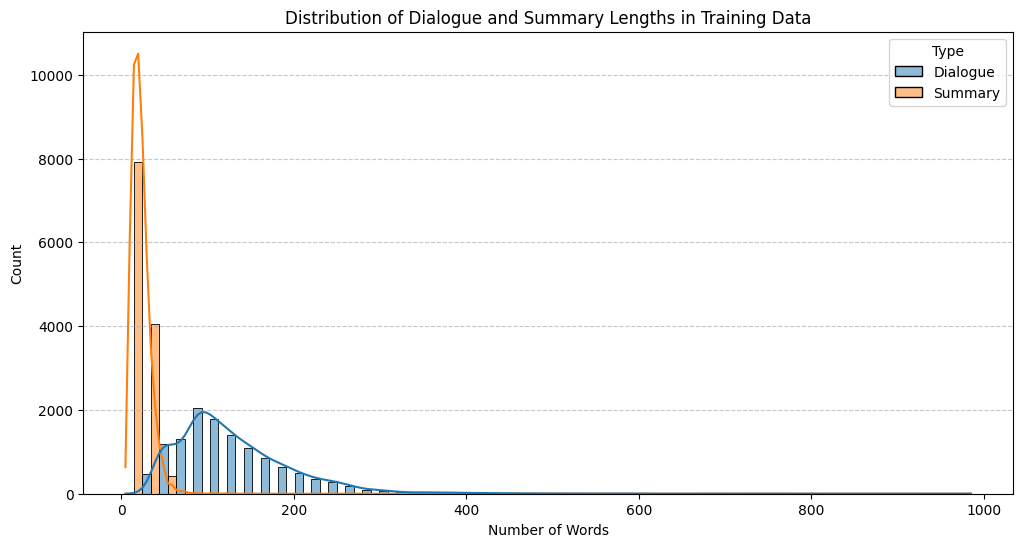

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate lengths of dialogues and summaries
dialogue_lengths = [len(dialogue.split()) for dialogue in ds['train']['dialogue']]
summary_lengths = [len(summary.split()) for summary in ds['train']['summary']]

# Create a DataFrame for easier plotting
df_lengths = pd.DataFrame({
    'Length': dialogue_lengths + summary_lengths,
    'Type': ['Dialogue'] * len(dialogue_lengths) + ['Summary'] * len(summary_lengths)
})

plt.figure(figsize=(12, 6))
sns.histplot(data=df_lengths, x='Length', hue='Type', multiple='dodge', bins=50, kde=True)
plt.title('Distribution of Dialogue and Summary Lengths in Training Data')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-2057693099.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=df_loss, palette='rocket')


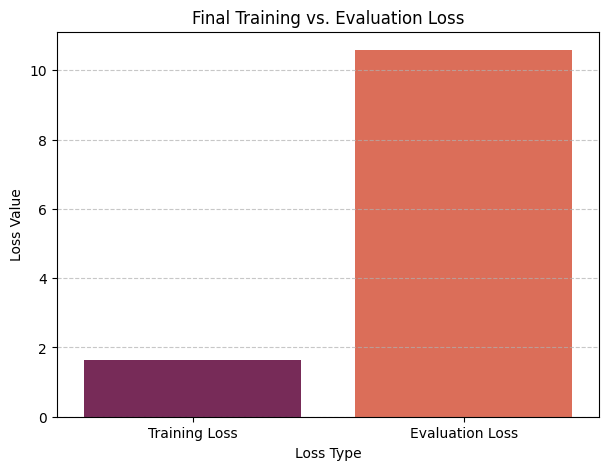

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extracting the final training loss from the last training output
# This value was obtained from the standard output of cell KVOyDvUN7Hl0
# TrainOutput(global_step=3116, training_loss=1.637715002997696, ...)
final_training_loss = 1.637715002997696

# The eval_results dictionary is already available in the kernel state
final_eval_loss = eval_results['eval_loss']

loss_data = {
    'Metric': ['Training Loss', 'Evaluation Loss'],
    'Value': [final_training_loss, final_eval_loss]
}

df_loss = pd.DataFrame(loss_data)

plt.figure(figsize=(7, 5))
sns.barplot(x='Metric', y='Value', data=df_loss, palette='rocket')
plt.title('Final Training vs. Evaluation Loss')
plt.ylabel('Loss Value')
plt.xlabel('Loss Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-1714794548.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=df_rouge, palette='viridis')


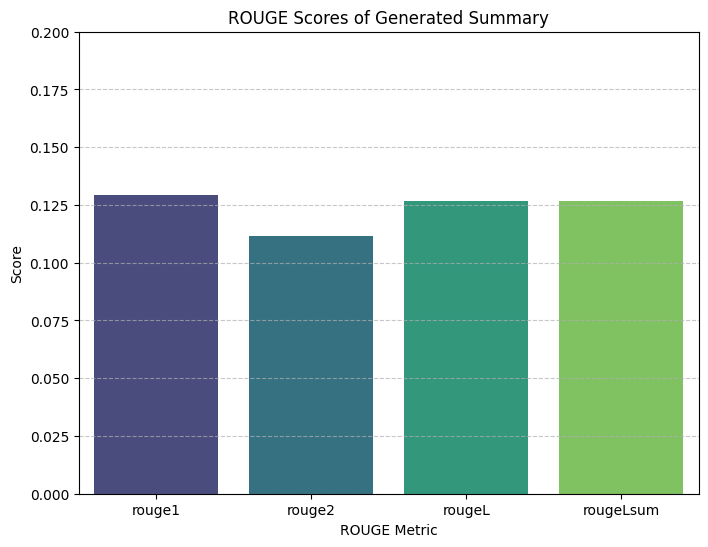

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'results' dictionary is available from previous execution
# {'rouge1': np.float64(0.12951807228915663), 'rouge2': np.float64(0.11178247734138973), 'rougeL': np.float64(0.12650602409638553), 'rougeLsum': np.float64(0.12650602409638553)}

rouge_scores = {
    'Metric': list(results.keys()),
    'Score': [float(value) for value in results.values()]
}

df_rouge = pd.DataFrame(rouge_scores)

plt.figure(figsize=(8, 6))
sns.barplot(x='Metric', y='Score', data=df_rouge, palette='viridis')
plt.title('ROUGE Scores of Generated Summary')
plt.ylabel('Score')
plt.xlabel('ROUGE Metric')
plt.ylim(0, 0.2) # Set y-limit to better visualize the scores if they are low
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()